# ECG SIGNAL NOISE ADDITION AND REMOVAL

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt, iirnotch

In [3]:
data=pd.read_csv(r"E:\Datasets\Datasets\ECG dataset for filtering and preprocessing.csv")
data

,Patient_ID,0,1,2,3,4,5,6,7,8,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,Annotation
0,P_1,0.019071,0.078773,0.160033,0.232172,0.288557,0.398010,0.509950,0.620232,0.732172,...,-0.018242,-0.015755,-0.015755,-0.015755,-0.015755,-0.015755,-0.014096,-0.011609,-0.009950,Sinus bradycardia
1,P_2,0.050514,0.047708,0.031805,0.045837,0.036483,0.038354,0.041160,0.043031,0.047708,...,0.062675,0.066417,0.069224,0.073901,0.078578,0.083255,0.086062,0.087933,0.090739,Sinus rhythm
2,P_3,-0.036412,-0.021636,-0.039050,-0.040106,-0.037467,-0.036412,-0.034828,-0.033773,-0.032190,...,-0.069129,-0.069129,-0.070185,-0.071768,-0.072823,-0.074406,-0.074406,-0.074406,-0.074406,Sinus rhythm
3,P_4,0.437252,0.525760,0.486129,0.433289,0.453104,0.446499,0.439894,0.433289,0.430647,...,-0.038309,-0.021136,-0.054161,-0.058124,0.001321,-0.027741,-0.120211,-0.107001,-0.034346,Sinus rhythm
4,P_5,0.092199,0.115248,0.106383,0.115248,0.115248,0.124113,0.132979,0.141844,0.150709,...,0.065603,0.062057,0.053191,0.044326,0.035461,0.030142,0.023050,0.012411,0.005319,Sinus rhythm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,P_196,-0.065033,-0.099906,-0.057493,-0.052780,-0.126296,-0.081056,-0.121583,-0.050895,-0.013195,...,-0.036758,0.010368,-0.022620,-0.010368,-0.010368,-0.055608,-0.041470,0.005655,0.038643,Sinus rhythm
196,P_197,-0.016414,-0.029040,-0.030934,-0.032197,-0.019571,-0.024621,-0.038510,-0.043561,-0.024621,...,0.016414,0.016414,0.011364,0.016414,0.011364,0.010101,0.005051,0.008207,-0.000631,Sinus arrhythmia
197,P_198,0.011211,0.005232,0.007474,0.003737,-0.001495,0.008969,0.008969,0.011211,0.023916,...,-0.046338,-0.053812,-0.059791,-0.057549,-0.053812,-0.053812,-0.059791,-0.046338,-0.044843,Sinus rhythm
198,P_199,0.136580,0.137767,0.145487,0.116983,0.106888,0.109857,0.103919,0.103919,0.108076,...,0.038005,0.024941,0.021971,0.029691,0.036817,0.023159,0.036817,0.027910,0.021971,Sinus rhythm


In [4]:
data.drop(['Patient_ID'],axis=1,inplace=True)
data

,0,1,2,3,4,5,6,7,8,9,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,Annotation
0,0.019071,0.078773,0.160033,0.232172,0.288557,0.398010,0.509950,0.620232,0.732172,0.815091,...,-0.018242,-0.015755,-0.015755,-0.015755,-0.015755,-0.015755,-0.014096,-0.011609,-0.009950,Sinus bradycardia
1,0.050514,0.047708,0.031805,0.045837,0.036483,0.038354,0.041160,0.043031,0.047708,0.061740,...,0.062675,0.066417,0.069224,0.073901,0.078578,0.083255,0.086062,0.087933,0.090739,Sinus rhythm
2,-0.036412,-0.021636,-0.039050,-0.040106,-0.037467,-0.036412,-0.034828,-0.033773,-0.032190,-0.025858,...,-0.069129,-0.069129,-0.070185,-0.071768,-0.072823,-0.074406,-0.074406,-0.074406,-0.074406,Sinus rhythm
3,0.437252,0.525760,0.486129,0.433289,0.453104,0.446499,0.439894,0.433289,0.430647,0.391017,...,-0.038309,-0.021136,-0.054161,-0.058124,0.001321,-0.027741,-0.120211,-0.107001,-0.034346,Sinus rhythm
4,0.092199,0.115248,0.106383,0.115248,0.115248,0.124113,0.132979,0.141844,0.150709,0.171986,...,0.065603,0.062057,0.053191,0.044326,0.035461,0.030142,0.023050,0.012411,0.005319,Sinus rhythm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.065033,-0.099906,-0.057493,-0.052780,-0.126296,-0.081056,-0.121583,-0.050895,-0.013195,-0.090481,...,-0.036758,0.010368,-0.022620,-0.010368,-0.010368,-0.055608,-0.041470,0.005655,0.038643,Sinus rhythm
196,-0.016414,-0.029040,-0.030934,-0.032197,-0.019571,-0.024621,-0.038510,-0.043561,-0.024621,-0.024621,...,0.016414,0.016414,0.011364,0.016414,0.011364,0.010101,0.005051,0.008207,-0.000631,Sinus arrhythmia
197,0.011211,0.005232,0.007474,0.003737,-0.001495,0.008969,0.008969,0.011211,0.023916,0.022422,...,-0.046338,-0.053812,-0.059791,-0.057549,-0.053812,-0.053812,-0.059791,-0.046338,-0.044843,Sinus rhythm
198,0.136580,0.137767,0.145487,0.116983,0.106888,0.109857,0.103919,0.103919,0.108076,0.111045,...,0.038005,0.024941,0.021971,0.029691,0.036817,0.023159,0.036817,0.027910,0.021971,Sinus rhythm


In [5]:
data.drop(['Annotation'],axis=1,inplace=True)


In [6]:
data

,0,1,2,3,4,5,6,7,8,9,...,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499
0,0.019071,0.078773,0.160033,0.232172,0.288557,0.398010,0.509950,0.620232,0.732172,0.815091,...,-0.018242,-0.018242,-0.015755,-0.015755,-0.015755,-0.015755,-0.015755,-0.014096,-0.011609,-0.009950
1,0.050514,0.047708,0.031805,0.045837,0.036483,0.038354,0.041160,0.043031,0.047708,0.061740,...,0.059869,0.062675,0.066417,0.069224,0.073901,0.078578,0.083255,0.086062,0.087933,0.090739
2,-0.036412,-0.021636,-0.039050,-0.040106,-0.037467,-0.036412,-0.034828,-0.033773,-0.032190,-0.025858,...,-0.069129,-0.069129,-0.069129,-0.070185,-0.071768,-0.072823,-0.074406,-0.074406,-0.074406,-0.074406
3,0.437252,0.525760,0.486129,0.433289,0.453104,0.446499,0.439894,0.433289,0.430647,0.391017,...,-0.050198,-0.038309,-0.021136,-0.054161,-0.058124,0.001321,-0.027741,-0.120211,-0.107001,-0.034346
4,0.092199,0.115248,0.106383,0.115248,0.115248,0.124113,0.132979,0.141844,0.150709,0.171986,...,0.076241,0.065603,0.062057,0.053191,0.044326,0.035461,0.030142,0.023050,0.012411,0.005319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.065033,-0.099906,-0.057493,-0.052780,-0.126296,-0.081056,-0.121583,-0.050895,-0.013195,-0.090481,...,-0.022620,-0.036758,0.010368,-0.022620,-0.010368,-0.010368,-0.055608,-0.041470,0.005655,0.038643
196,-0.016414,-0.029040,-0.030934,-0.032197,-0.019571,-0.024621,-0.038510,-0.043561,-0.024621,-0.024621,...,0.015152,0.016414,0.016414,0.011364,0.016414,0.011364,0.010101,0.005051,0.008207,-0.000631
197,0.011211,0.005232,0.007474,0.003737,-0.001495,0.008969,0.008969,0.011211,0.023916,0.022422,...,-0.050075,-0.046338,-0.053812,-0.059791,-0.057549,-0.053812,-0.053812,-0.059791,-0.046338,-0.044843
198,0.136580,0.137767,0.145487,0.116983,0.106888,0.109857,0.103919,0.103919,0.108076,0.111045,...,0.032067,0.038005,0.024941,0.021971,0.029691,0.036817,0.023159,0.036817,0.027910,0.021971


Text(0.5, 1.0, 'pure ECG signal')

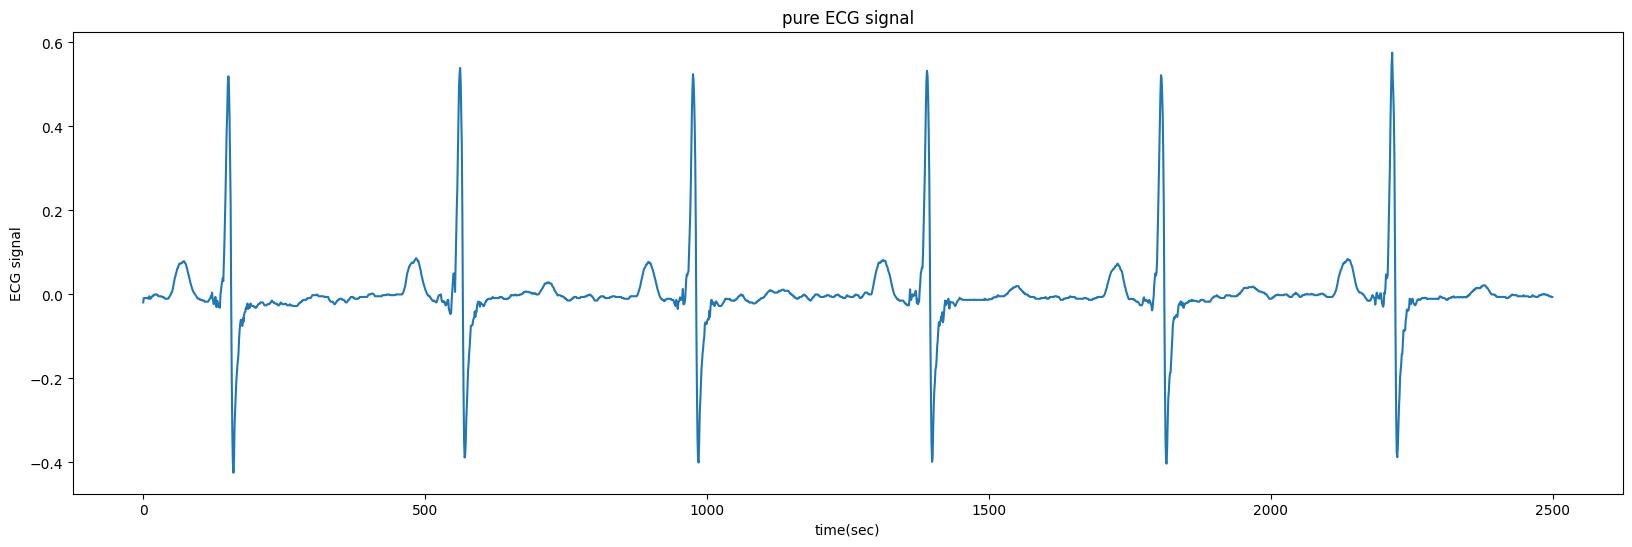

In [7]:
plt.figure(figsize=(20,6))
plt.plot(data.iloc[20].values)
plt.xlabel("time(sec)");
plt.ylabel("ECG signal")
plt.title("pure ECG signal")

# Simulation of 50Hz noise

In [8]:
len(data.iloc[20])

2500

In [9]:
ecg_signal=data.iloc[20]
noise_freq=50
noise_amp=0.05
fs=500;
t=np.arange(len(data.iloc[20]))/fs
noise=noise_amp*np.sin(2*np.pi*noise_freq*t)
ecg_noisy=ecg_signal+noise
ecg_noisy

0      -0.018982
1       0.020761
2       0.038925
3       0.038925
4       0.020761
          ...   
2495   -0.004314
2496   -0.033703
2497   -0.053593
2498   -0.053593
2499   -0.035429
Name: 20, Length: 2500, dtype: float64

Text(0.5, 1.0, 'noisy ECG signal')

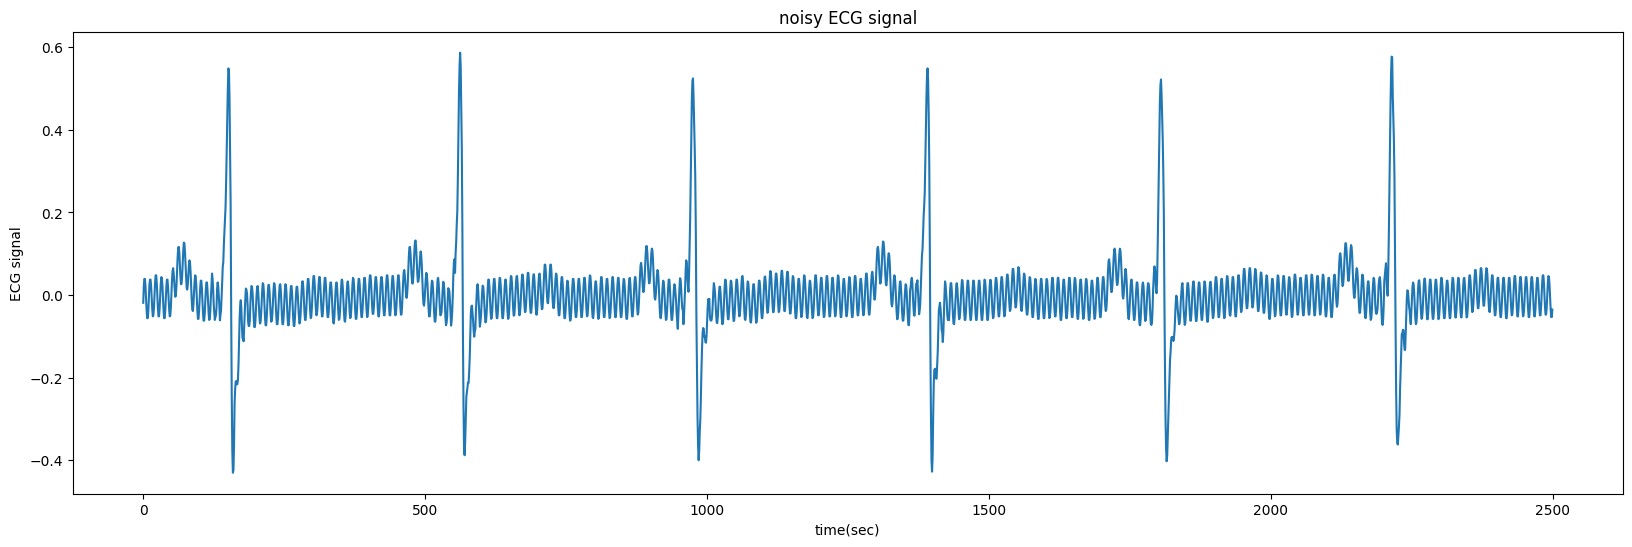

In [10]:
plt.figure(figsize=(20,6))
plt.plot(ecg_noisy.values)
plt.xlabel("time(sec)");
plt.ylabel("ECG signal")
plt.title("noisy ECG signal")

# FILTERING

In [11]:
notch_freq=50
Q=30.0;
b,a=iirnotch(notch_freq,Q,fs)
ecg_notch=filtfilt(b,a,ecg_noisy)

In [12]:
def butter_lowpass(lowcut,fs,order=22):
    nyquist=0.5*fs
    low=lowcut/nyquist
    b,a=butter(order,low,btype='low')
    return b,a
b,a=butter_lowpass(40,fs)
ecg_lowpassed=filtfilt(b,a,ecg_noisy)
    


Text(0.5, 1.0, 'Filtered noisless ECG signal')

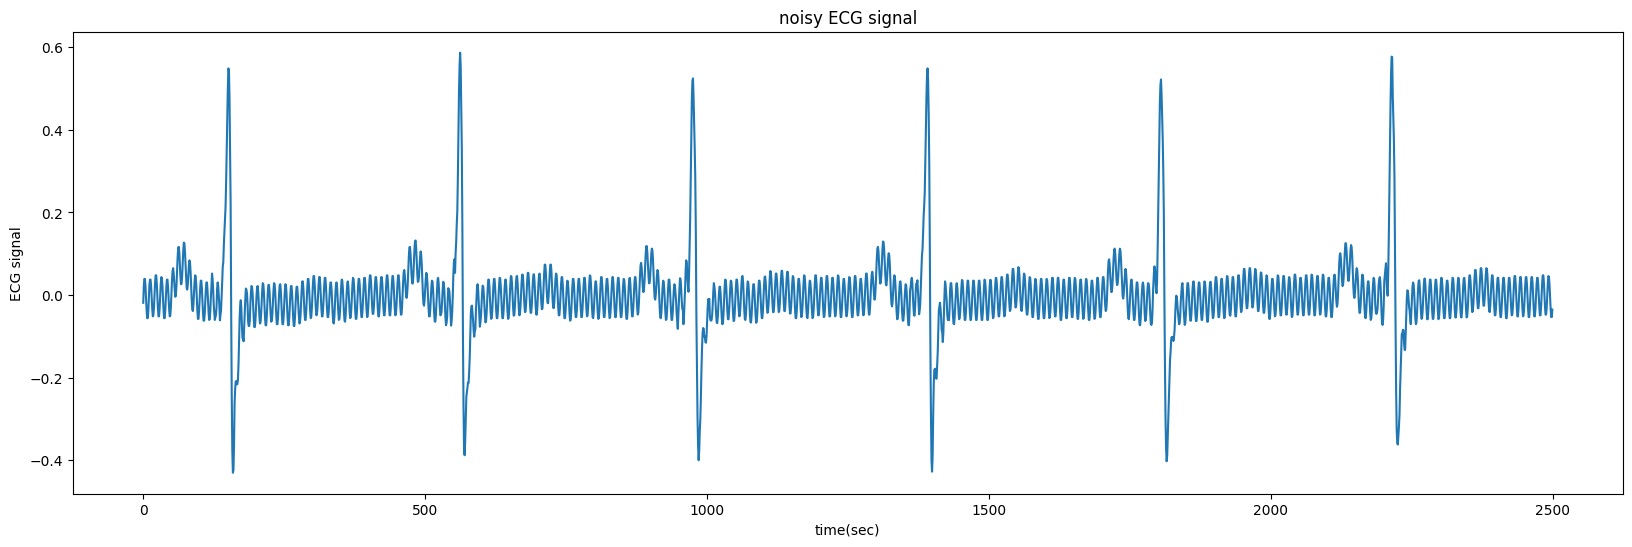

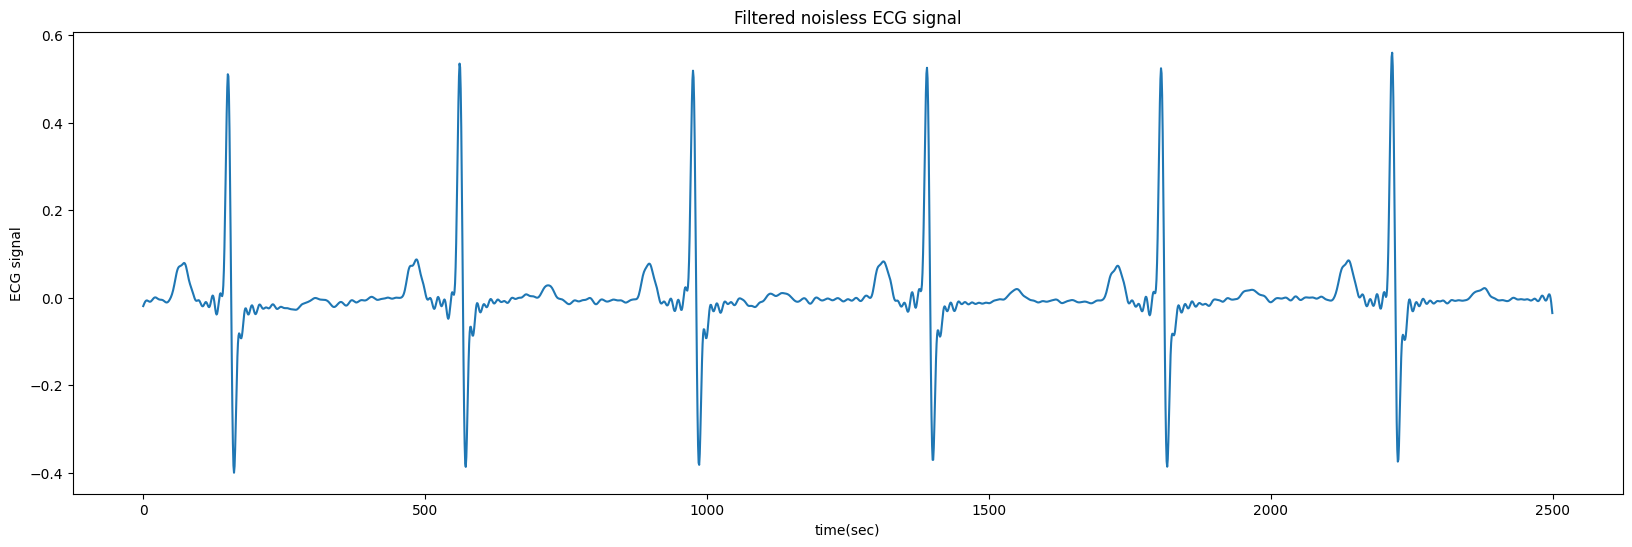

In [13]:
plt.figure(figsize=(20,6))
plt.plot(ecg_noisy.values)
plt.xlabel("time(sec)");
plt.ylabel("ECG signal")
plt.title("noisy ECG signal")
plt.figure(figsize=(20,6))
plt.plot(ecg_lowpassed)
plt.xlabel("time(sec)");
plt.ylabel("ECG signal")
plt.title("Filtered noisless ECG signal")

# SNR CALCULATION

In [14]:
def calculate_snr(original,noisy):
    signal_power=np.sum(original**2)
    noisy_power=np.sum((original-noisy)**2)
    return 10*np.log10(signal_power/noisy_power)
   

In [15]:
snr_noisy=calculate_snr(ecg_signal,ecg_noisy)
snr_notch=calculate_snr(ecg_signal,ecg_notch)
snr_lowpass=calculate_snr(ecg_signal,ecg_lowpassed)
print(f"SNR OF NOISY SIGNAL:",snr_noisy,"dB")
print(f"SNR OF NOtch filtered  SIGNAL: ",(snr_notch),"dB")
print(f"SNR OF lowpass filtered  SIGNAL: ",(snr_lowpass),"dB")

SNR OF NOISY SIGNAL: 7.534586675740097 dB
SNR OF NOtch filtered  SIGNAL:  29.45841645312501 dB
SNR OF lowpass filtered  SIGNAL:  16.16053919927904 dB
